# Processing log files

This is for processing the data from the ``PackedRingBuffer``


In [2]:
# Helper methods and imports. Run this first and then any other cell will run
import numpy as np
import math
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import re
from datetime import datetime
import mpl_axes_aligner



In [10]:
data_dir = Path("data") 

In [192]:
# Extract sensor buffer entries from all .txt files in data_dir and save each to CSV

txt_files = sorted(data_dir.glob('*.txt'))
if not txt_files:
    print(f'No .txt files found in: {data_dir.resolve()}')

# FL, LA, RA, FR, dCount, mazeLoc, fwdSpeed, rotSpeed, leftV, rightV
data_columns = [
    'Front Left',
    'Left Angle',
    'Right Angle',
    'Front Right',
    'Distance Count',
    'Maze Location',
    'Forward Speed count',
    'Rotation Speed count',
    'Left Motor Volts Scaled',
    'Right Motor Volts Scaled',
]

sensor_pattern = re.compile(r"Robot Data:\s*\[([^\]]+)\]")

# Set your conversion factors here
MM_per_Count = 0.177836584164  # mm per count
DEG_per_Count = 0.135857142857  # deg per count

processed = 0
for log_path in txt_files:
    rows = []

    with log_path.open('r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            match = sensor_pattern.search(line)
            if not match:
                continue

            values = [int(x.strip()) for x in match.group(1).split(',')]
            if len(values) == len(data_columns):
                rows.append(values)

    sensor_df = pd.DataFrame(rows, columns=data_columns)

    sensor_df['Front sum'] = sensor_df['Front Left'] + sensor_df['Front Right']
    sensor_df['Front diff'] = sensor_df['Front Left'] - sensor_df['Front Right']

    # Ensure numeric type for safety
    sensor_df['Distance Count'] = pd.to_numeric(sensor_df['Distance Count'], errors='coerce').fillna(0)

    # 1) Integrated distance count (running sum)
    sensor_df['Distance Count Travelled'] = sensor_df['Distance Count'].cumsum()

    # 2) Converted integrated distance
    sensor_df['Distance MM'] = sensor_df['Distance Count Travelled'] * MM_per_Count

    sensor_df['Profile Forward Speed mm'] = sensor_df['Forward Speed count'] * MM_per_Count
    sensor_df['Profile Rotation Speed deg'] = sensor_df['Rotation Speed count'] * DEG_per_Count

    # Magic number from your scaling/packing system; value sent to motor controller
    sensor_df['LeftVolts'] = sensor_df['Left Motor Volts Scaled'] * 0.036
    sensor_df['RightVolts'] = sensor_df['Right Motor Volts Scaled'] * 0.036

    sensor_df['Maze X'] = sensor_df['Maze Location'] // 16
    sensor_df['Maze Y'] = sensor_df['Maze Location'] % 16

    output_csv = data_dir / f'{log_path.stem}_data.csv'
    sensor_df.to_csv(output_csv, index=False)

    processed += 1
    print(f'[{processed}/{len(txt_files)}] Extracted {len(sensor_df)} rows from {log_path.name}')
    print(f'    Saved CSV to: {output_csv.resolve()}')

if processed:
    # Show the last processed DataFrame preview for convenience
    display(sensor_df.head())



[1/4] Extracted 5246 rows from 20260306Search1.txt
    Saved CSV to: /home/paul/MicroMouseTools/Reporting/data/20260306Search1_data.csv
[2/4] Extracted 834 rows from 20260306Speed1.txt
    Saved CSV to: /home/paul/MicroMouseTools/Reporting/data/20260306Speed1_data.csv
[3/4] Extracted 211 rows from _run1.txt
    Saved CSV to: /home/paul/MicroMouseTools/Reporting/data/_run1_data.csv
[4/4] Extracted 1056 rows from serial_20260306_145734.txt
    Saved CSV to: /home/paul/MicroMouseTools/Reporting/data/serial_20260306_145734_data.csv


,Front Left,Left Angle,Right Angle,Front Right,Distance Count,Maze Location,Forward Speed count,Rotation Speed count,Left Motor Volts Scaled,Right Motor Volts Scaled,Front sum,Front diff,Distance Count Travelled,Distance MM,Profile Forward Speed mm,Profile Rotation Speed deg,LeftVolts,RightVolts,Maze X,Maze Y
0,3,105,93,3,12,0,1400,0,66,70,6,0,12,2.134039,248.971218,0.0,2.376,2.520,0,0
1,2,107,92,2,19,0,1960,0,79,76,4,0,31,5.512934,348.559705,0.0,2.844,2.736,0,0
2,2,109,93,2,14,0,2240,0,89,82,4,0,45,8.002646,398.353949,0.0,3.204,2.952,0,0
3,2,108,92,1,18,0,2520,0,93,86,3,1,63,11.203705,448.148192,0.0,3.348,3.096,0,0
4,2,109,93,2,21,0,2800,0,100,94,4,0,84,14.938273,497.942436,0.0,3.600,3.384,0,0


In [183]:
def align_yaxis(ax1, v1, ax2, v2):
    """Shift ax2 so v2 in ax2 aligns with v1 in ax1 (in display coords)."""
    _, y1 = ax1.transData.transform((0, v1))
    _, y2 = ax2.transData.transform((0, v2))
    inv = ax2.transData.inverted()
    _, dy = inv.transform((0, 0)) - inv.transform((0, y1 - y2))
    y_min, y_max = ax2.get_ylim()
    ax2.set_ylim(y_min + dy, y_max + dy)

start_x = 188#48      # configurable first line
spacing = 180      # configurable gap between lines

rightThreadhold = 50
leftThreadhold = 40
frontThreadhold = 40

In [184]:

def add_rolling_drop_triggers(
    df,
    cols=('Left Angle', 'Right Angle'),
    window=20,           # X samples in rolling window
    drop_ratio=0.5,      # trigger when sample < drop_ratio * rolling_max
    min_peak=50,         # ignore low-amplitude windows
    refractory=8         # minimum samples between triggers
):
    out = df.copy()

    for col in cols:
        s = pd.to_numeric(out[col], errors='coerce').fillna(0)

        # Max over previous X samples (shifted so current sample is "next sample")
        roll_max = s.rolling(window=window, min_periods=1).max().shift(1)

        raw_trigger = (s < drop_ratio * roll_max) & (roll_max >= min_peak)
        raw_trigger = raw_trigger.fillna(False)

        # Debounce/refractory
        trig = pd.Series(False, index=out.index)
        last_idx = -10**9
        for i in out.index[raw_trigger]:
            if (i - last_idx) > refractory:
                trig.loc[i] = True
                last_idx = i

        out[f'{col} RollingMax_{window}'] = roll_max
        out[f'{col} DropTriggerRaw'] = raw_trigger
        out[f'{col} TriggerPoint'] = trig

    return out




# Create volts vs profile image for everything 

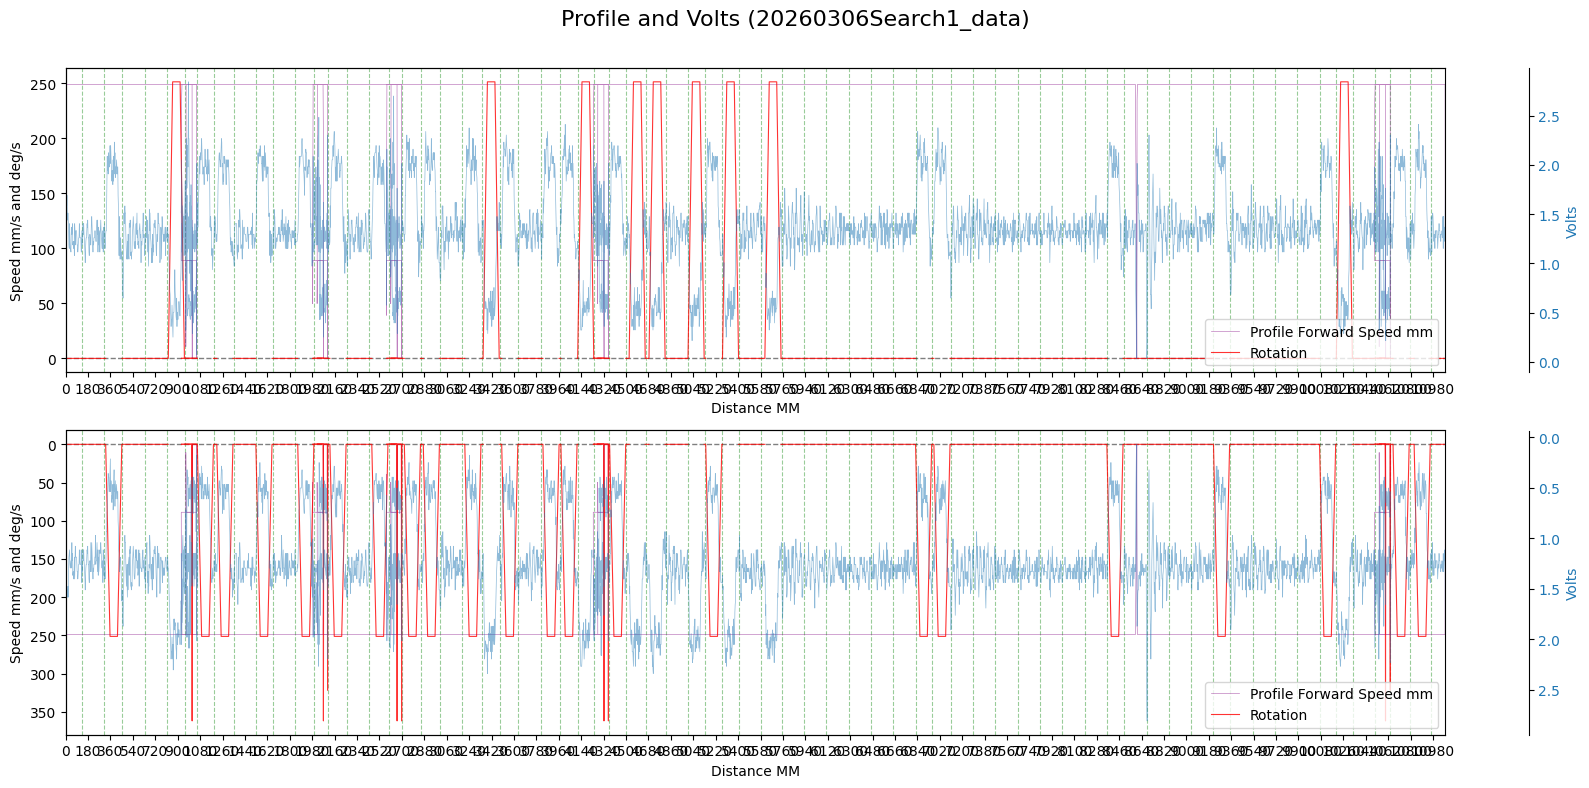

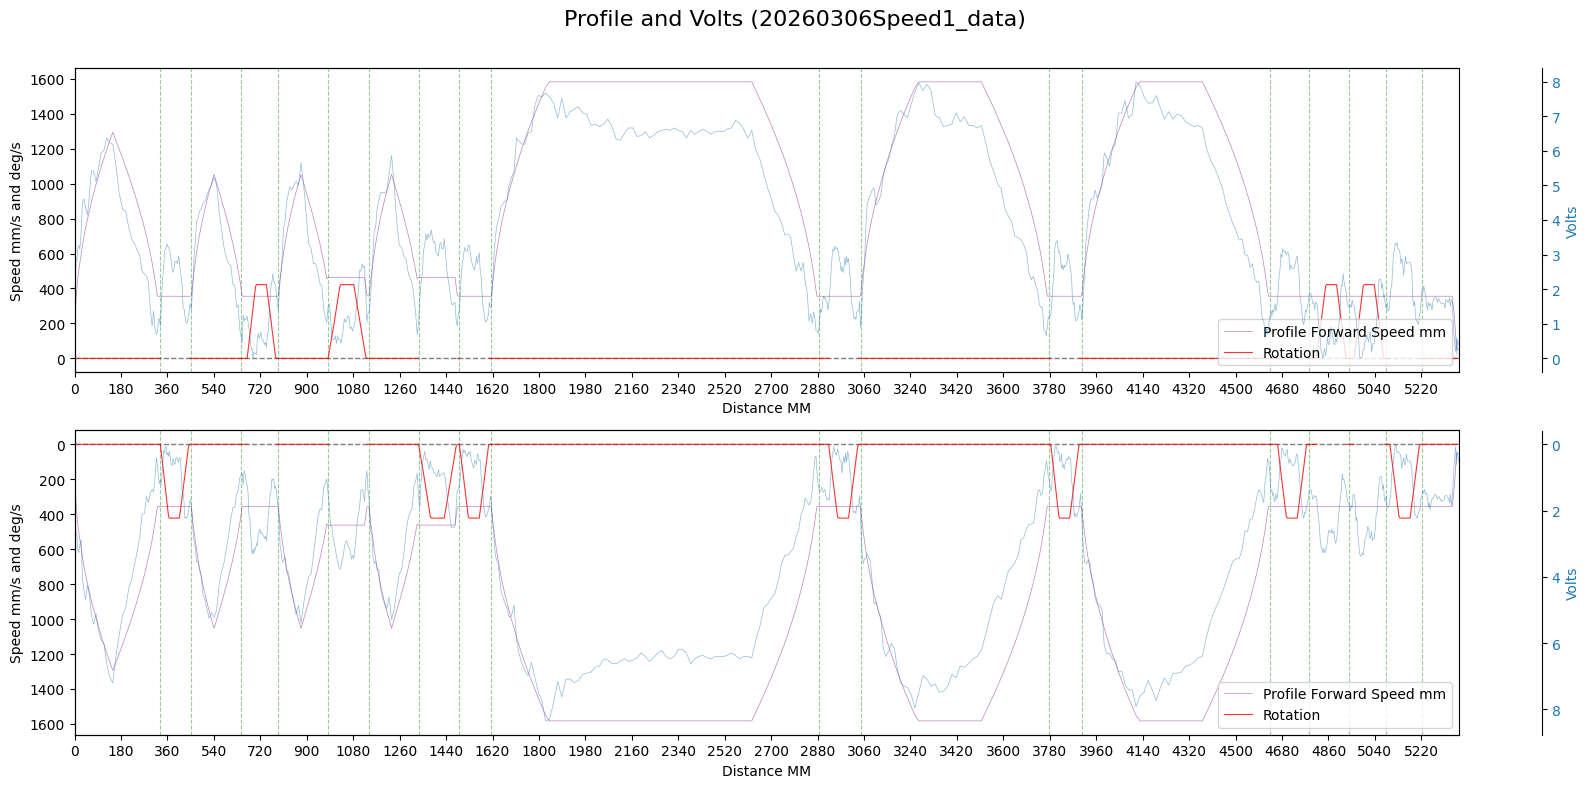

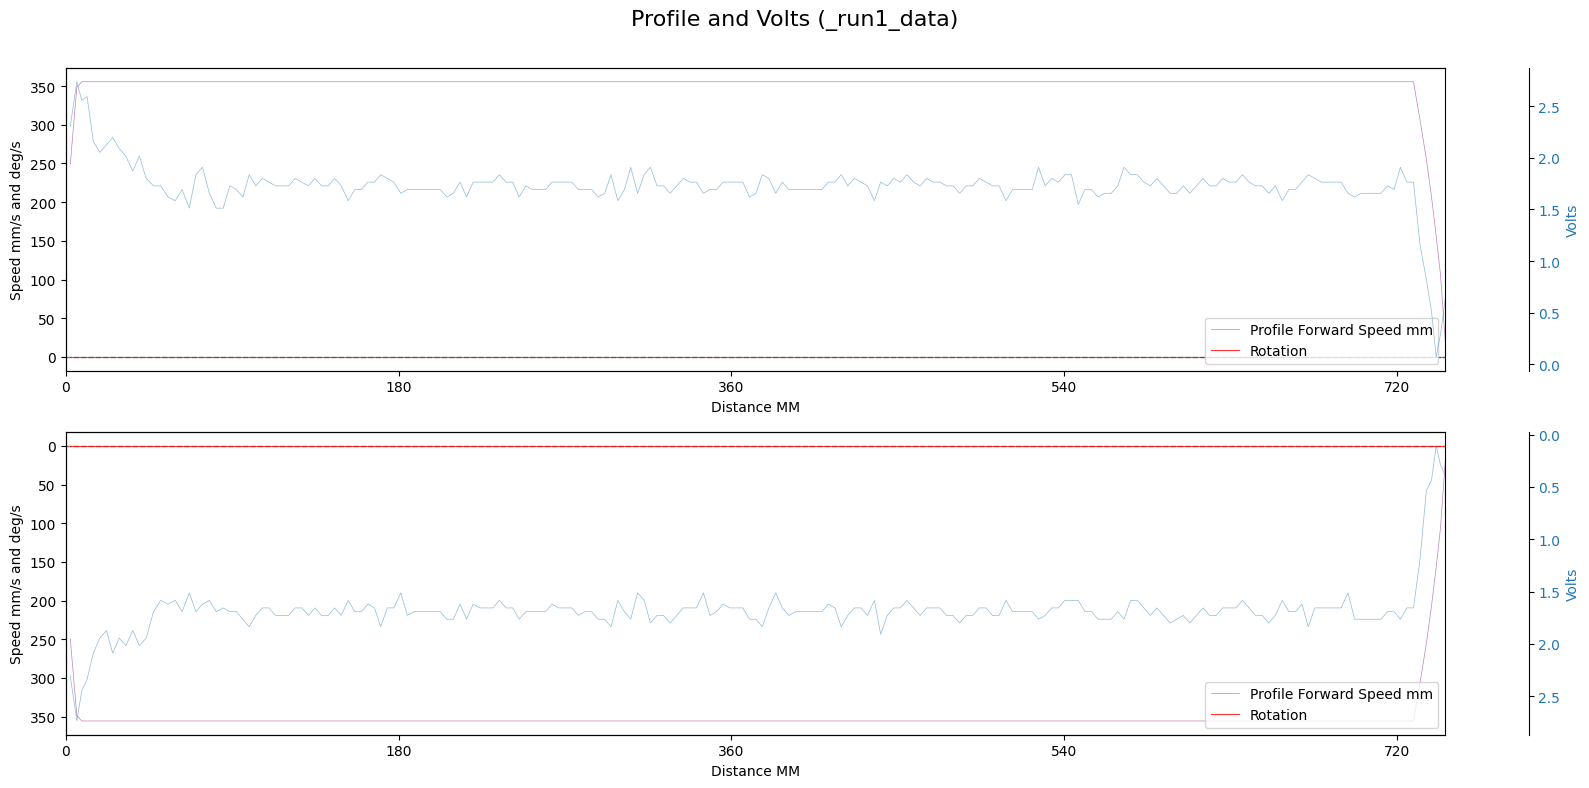

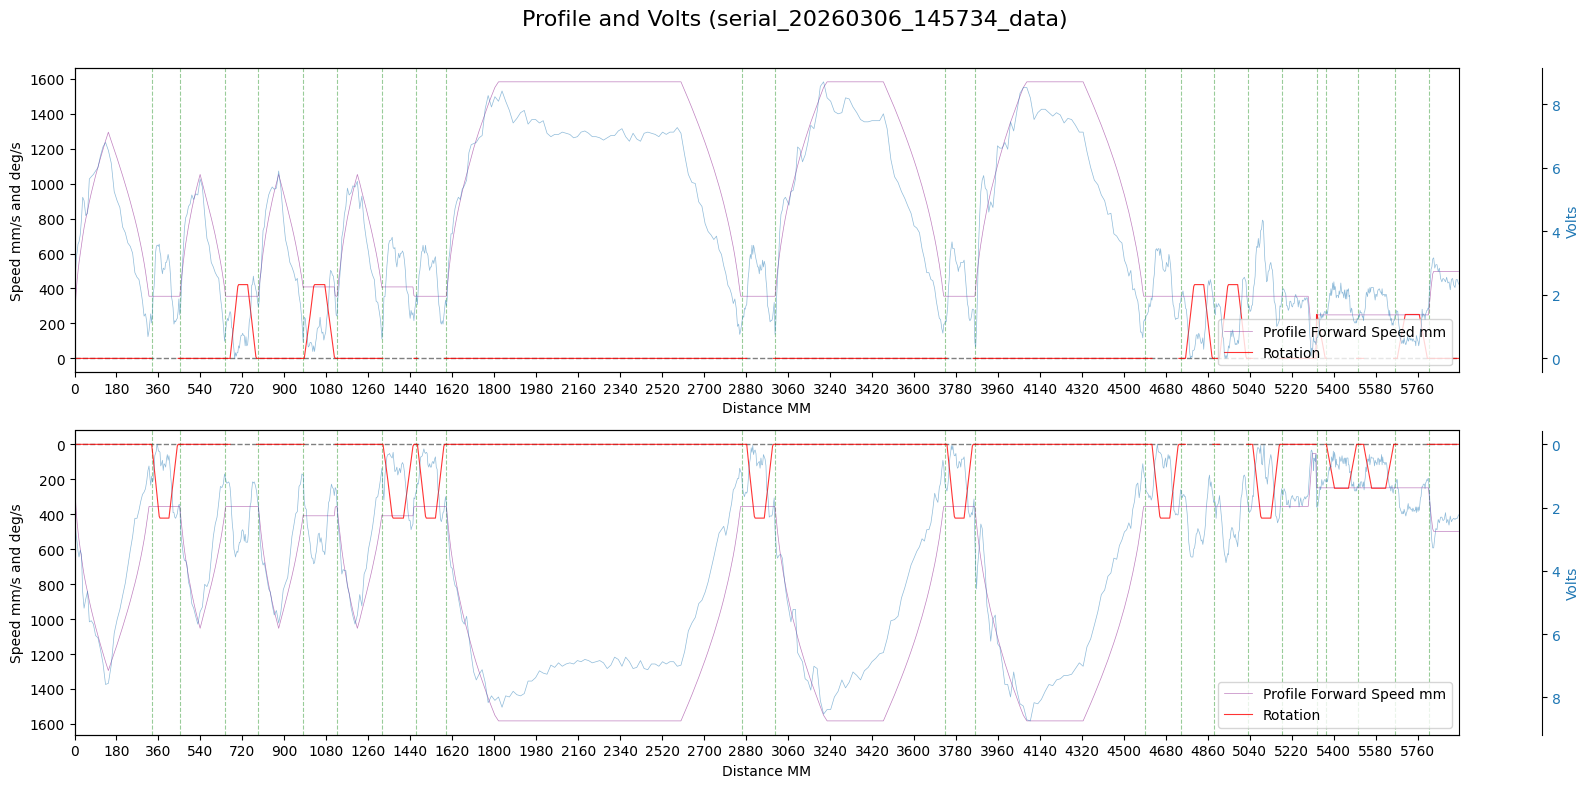

In [193]:

csv_files = sorted(data_dir.glob('*.csv'))

for log_path in csv_files:

    data_csv = Path(log_path)

    df = pd.read_csv(data_csv)

    # x-positions where maze location changes (row-to-row)
    change_x = df.loc[df['Maze Location'].ne(df['Maze Location'].shift()), 'Distance MM']
    #skip first row (it always counts as a "change" from NaN)
    change_x = change_x.iloc[1:]

    # setup plot layout
    fig = plt.figure(figsize=(16, 8))
    plotLayout = (2, 1)
    ax_left = plt.subplot2grid(plotLayout, (0, 0))
    ax_right = plt.subplot2grid(plotLayout, (1, 0))


    Xaxis = df['Distance MM']  # or df.index if index is your x-axis

    xLimitLow = 0
    xLimitHigh = Xaxis.max()  # or df.index.max() if index is your x-axis
    rot = df['Profile Rotation Speed deg']

    # Keep only left turns (positive)
    rot_left = rot.where(rot >= 0)              # negatives -> NaN (not drawn)

    # Keep only right turns (negative), then flip to positive magnitude
    rot_right = (-rot.where(rot <= 0)) 

    for ax in ((ax_left, ax_right)):

        ax.set_xlim(left=xLimitLow, right=xLimitHigh)
        ax.set_xticks(np.arange(xLimitLow, xLimitHigh + 1, 180))

        for x in change_x:
            ax.axvline(x=x, color='Green', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        # plot on new axis
        ax.plot(Xaxis, df['Profile Forward Speed mm'].abs(), color='purple', linewidth=0.5, label='Profile Forward Speed mm', alpha=0.5)


    ax_left.plot(Xaxis, rot_left, color='red', linewidth=0.8, alpha=0.8, label='Rotation')
    ax_right.plot(Xaxis, rot_right, color='red', linewidth=0.8, alpha=0.8, label='Rotation')

    ax_volts = ax_left.twinx()
    ax_volts.spines['right'].set_position(('outward', 60))  # shift 60 px
    ax_volts.plot(df['Distance MM'], df['LeftVolts'], color='tab:blue', linewidth=0.5, label='Left Volts', alpha=0.5)
    ax_volts.set_ylabel('Volts', color='tab:blue')
    ax_volts.tick_params(axis='y', labelcolor='tab:blue')

    ax_volts = ax_right.twinx()
    ax_volts.spines['right'].set_position(('outward', 60))  # shift 60 px
    ax_volts.plot(df['Distance MM'], df['RightVolts'], color='tab:blue', linewidth=0.5, label='Right Volts', alpha=0.5)
    ax_volts.set_ylabel('Volts', color='tab:blue')
    ax_volts.tick_params(axis='y', labelcolor='tab:blue')
    ax_volts.invert_yaxis()


    ax_left.legend(loc='lower right')
    ax_left.set_ylabel('Speed mm/s and deg/s')
    ax_left.set_xlabel('Distance MM')

    ax_right.invert_yaxis()
    ax_right.legend(loc='lower right')
    ax_right.set_ylabel('Speed mm/s and deg/s')
    ax_right.set_xlabel('Distance MM')

    fig.suptitle(f'Profile and Volts ({log_path.stem})', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    #plt.show()
    image_path = data_dir / Path("plots") / f"{log_path.stem}ProfileVolts_plot.png"
    fig.savefig(image_path, dpi=300, bbox_inches='tight')



# Full plots

In [194]:
file_name = "_run1_data.csv"

log_path = data_dir / file_name

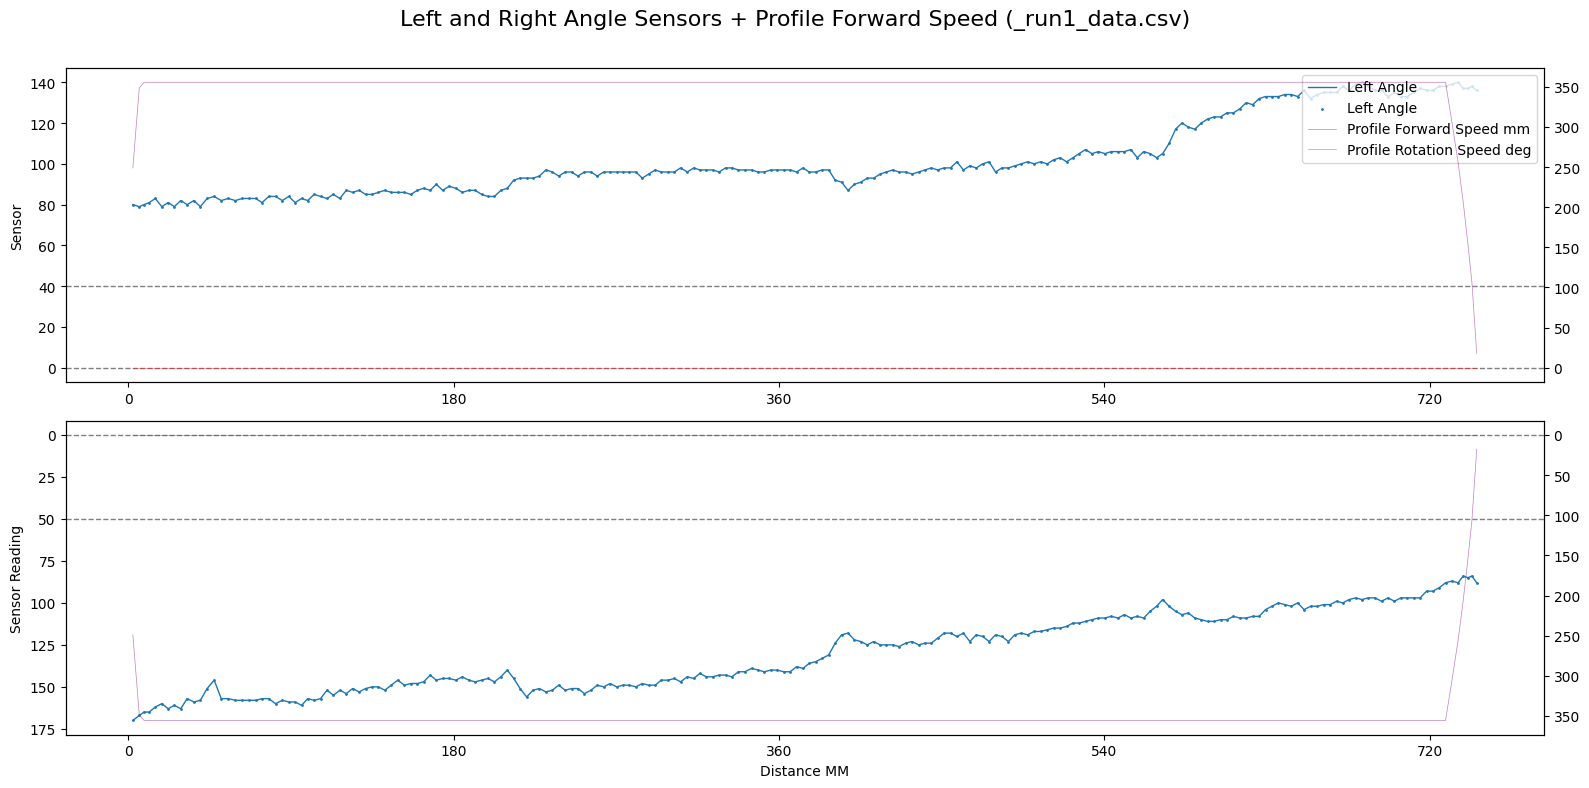

In [199]:
data_csv = Path(log_path)

df = pd.read_csv(data_csv)

# Build detection dataset
df_det = add_rolling_drop_triggers(
    df,
    cols=('Left Angle', 'Right Angle'),
    window=8,
    drop_ratio=0.5,
    min_peak=50,
    refractory=8
)

# choose an x max that covers your plotted data
x_max = df['Distance MM'].max()  # or df.index.max() if index is your x-axis
x_lines = np.arange(start_x, x_max + spacing, spacing)

# x-positions where maze location changes (row-to-row)
change_x = df.loc[df['Maze Location'].ne(df['Maze Location'].shift()), 'Distance MM']
#skip first row (it always counts as a "change" from NaN)
change_x = change_x.iloc[1:]

# setup plot layout
fig = plt.figure(figsize=(16, 8))
plotLayout = (2, 1)
ax_left = plt.subplot2grid(plotLayout, (0, 0))
ax_right = plt.subplot2grid(plotLayout, (1, 0))

sensor_cols = [
    'Front sum',
    'Left Angle',
    'Right Angle',
]

w_fast = 0.2
w_slow = 0.0625

Xaxis = df['Distance MM']  # or df.index if index is your x-axis
rot = df['Profile Rotation Speed deg']

# Keep only left turns (positive)
rot_left = rot.where(rot >= 0)              # negatives -> NaN (not drawn)

# Keep only right turns (negative), then flip to positive magnitude
rot_right = (-rot.where(rot <= 0)) 


ax_left.axhline(y=leftThreadhold, color='black', linestyle='--', linewidth=1, alpha=0.5)    
ax_right.axhline(y=rightThreadhold, color='black', linestyle='--', linewidth=1, alpha=0.5)


ax_left.plot(Xaxis, df['Left Angle'], label='Left Angle', lw=1)
ax_left.scatter(Xaxis, df['Left Angle'], label='Left Angle', s=1)
ax_right.plot(Xaxis, df['Right Angle'], label='Right Angle', lw=1)
ax_right.scatter(Xaxis, df['Right Angle'], label='Right Angle', s=1)



# draw lines on one axis
# 

ax_left.legend(loc='best', fontsize=8)

ax_left.set_ylabel('Sensor')


for ax in ((ax_left, ax_right)):
    x0, x1 = ax.get_xlim()
    xticks = np.arange(0, x1, 180)
    ax.set_xticks(xticks)
    #ax.set_xlim(left=0, right=2000)

    for x in change_x:
        ax.axvline(x=x, color='Green', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)


# plot on new axis
ax_speed = ax_left.twinx()
ax_speed.plot(Xaxis, df['Profile Forward Speed mm'].abs(), color='purple', linewidth=0.5, label='Profile Forward Speed mm', alpha=0.5)
    
ax_speed.plot(Xaxis, rot_left, color='red', linewidth=0.5, label='Profile Rotation Speed deg', alpha=0.5)


ax_speed = ax_right.twinx()
ax_speed.plot(Xaxis, df['Profile Forward Speed mm'].abs(), color='purple', linewidth=0.5, label='Profile Forward Speed mm', alpha=0.5)
ax_speed.plot(Xaxis, rot_right, color='red', linewidth=0.5, label='Profile Rotation Speed deg', alpha=0.5)   

ax_speed.invert_yaxis()




h1, l1 = ax_left.get_legend_handles_labels()
h2, l2 = ax_speed.get_legend_handles_labels()
ax_left.legend(h1 + h2, l1 + l2, loc='upper right')


ax_right.invert_yaxis()
ax_right.set_ylabel('Sensor Reading')
ax_right.set_xlabel('Distance MM')

image_path = data_dir / f"{log_path.stem}AngleSensorProfile_plot.png"
fig.suptitle(f'Left and Right Angle Sensors + Profile Forward Speed ({file_name})', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
image_path = data_dir / Path("plots") / f"{log_path.stem}AngleSensorProfile_plot.png"
#fig.savefig(image_path, dpi=300, bbox_inches='tight')



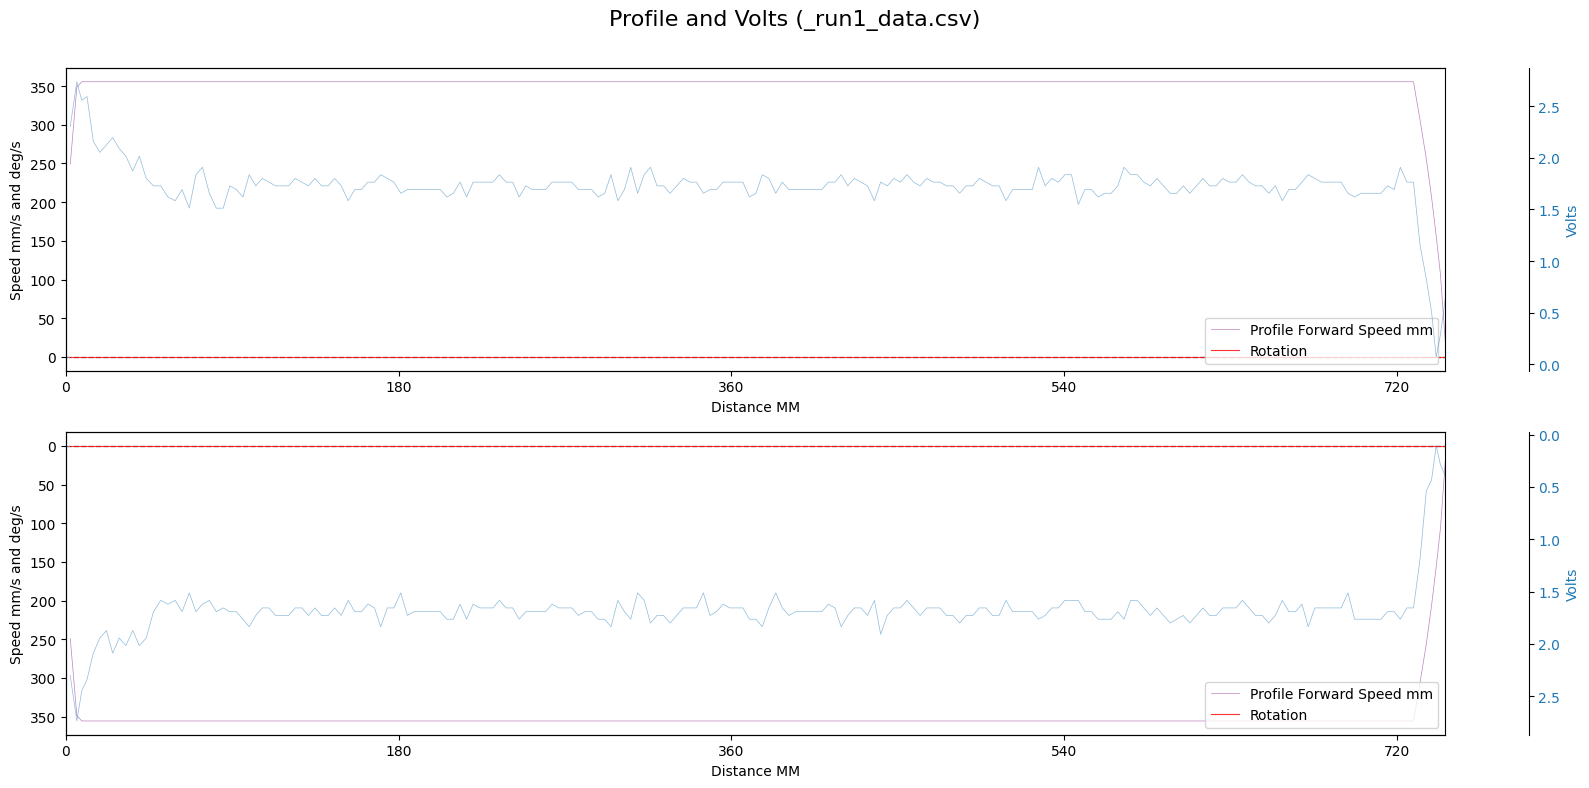

In [200]:
data_csv = Path(log_path)

df = pd.read_csv(data_csv)




# x-positions where maze location changes (row-to-row)
change_x = df.loc[df['Maze Location'].ne(df['Maze Location'].shift()), 'Distance MM']
#skip first row (it always counts as a "change" from NaN)
change_x = change_x.iloc[1:]

# setup plot layout
fig = plt.figure(figsize=(16, 8))
plotLayout = (2, 1)
ax_left = plt.subplot2grid(plotLayout, (0, 0))
ax_right = plt.subplot2grid(plotLayout, (1, 0))


Xaxis = df['Distance MM']  # or df.index if index is your x-axis

xLimitLow = 0
xLimitHigh = Xaxis.max()  # or df.index.max() if index is your x-axis
rot = df['Profile Rotation Speed deg']

# Keep only left turns (positive)
rot_left = rot.where(rot >= 0)              # negatives -> NaN (not drawn)

# Keep only right turns (negative), then flip to positive magnitude
rot_right = (-rot.where(rot <= 0)) 

for ax in ((ax_left, ax_right)):

    ax.set_xlim(left=xLimitLow, right=xLimitHigh)
    ax.set_xticks(np.arange(xLimitLow, xLimitHigh + 1, 180))

    for x in change_x:
        ax.axvline(x=x, color='Green', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    # plot on new axis
    ax.plot(Xaxis, df['Profile Forward Speed mm'].abs(), color='purple', linewidth=0.5, label='Profile Forward Speed mm', alpha=0.5)


ax_left.plot(Xaxis, rot_left, color='red', linewidth=0.8, alpha=0.8, label='Rotation')
ax_right.plot(Xaxis, rot_right, color='red', linewidth=0.8, alpha=0.8, label='Rotation')

ax_volts = ax_left.twinx()
ax_volts.spines['right'].set_position(('outward', 60))  # shift 60 px
ax_volts.plot(df['Distance MM'], df['LeftVolts'], color='tab:blue', linewidth=0.5, label='Left Volts', alpha=0.5)
ax_volts.set_ylabel('Volts', color='tab:blue')
ax_volts.tick_params(axis='y', labelcolor='tab:blue')

ax_volts = ax_right.twinx()
ax_volts.spines['right'].set_position(('outward', 60))  # shift 60 px
ax_volts.plot(df['Distance MM'], df['RightVolts'], color='tab:blue', linewidth=0.5, label='Right Volts', alpha=0.5)
ax_volts.set_ylabel('Volts', color='tab:blue')
ax_volts.tick_params(axis='y', labelcolor='tab:blue')
ax_volts.invert_yaxis()


ax_left.legend(loc='lower right')
ax_left.set_ylabel('Speed mm/s and deg/s')
ax_left.set_xlabel('Distance MM')

ax_right.invert_yaxis()
ax_right.legend(loc='lower right')
ax_right.set_ylabel('Speed mm/s and deg/s')
ax_right.set_xlabel('Distance MM')

fig.suptitle(f'Profile and Volts ({file_name})', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
image_path = data_dir/ Path("plots") / f"{log_path.stem}ProfileVolts_plot.png"
fig.savefig(image_path, dpi=300, bbox_inches='tight')



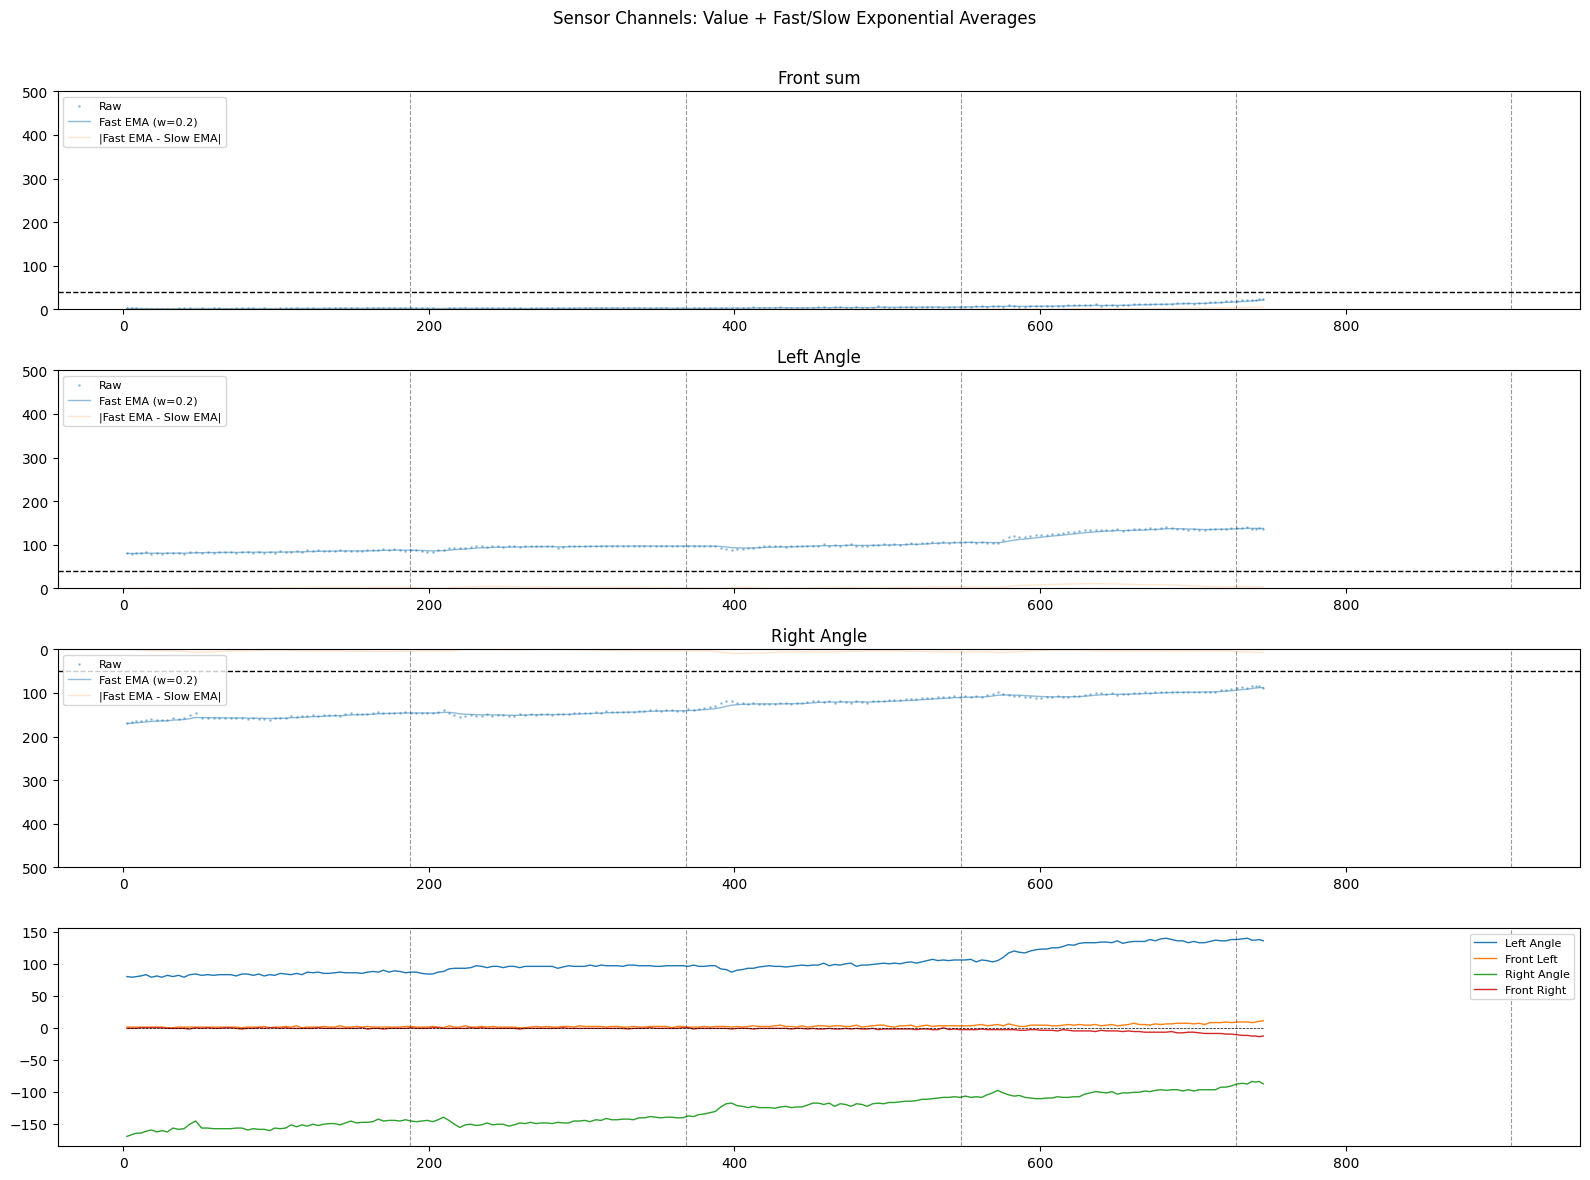

In [197]:
data_csv = Path(log_path)

df = pd.read_csv(data_csv)
fig = plt.figure(figsize=(16, 12))



# choose an x max that covers your plotted data
x_max = df['Distance MM'].max()  # or df.index.max() if index is your x-axis

x_lines = np.arange(start_x, x_max + spacing, spacing)

plotLayout = (4, 1)

ax1 = plt.subplot2grid(plotLayout, (0, 0))
ax2 = plt.subplot2grid(plotLayout, (1, 0))
ax3 = plt.subplot2grid(plotLayout, (2, 0))
ax4 = plt.subplot2grid(plotLayout, (3, 0))

sensor_cols = [
    'Front sum',
    'Left Angle',
    'Right Angle',
]

w_fast = 0.2
w_slow = 0.0625

Xaxis = df['Distance MM']  # or df.index if index is your x-axis

for ax, col in zip((ax1, ax2, ax3), sensor_cols):
    fast_ema = df[col].ewm(alpha=w_fast, adjust=False).mean()
    slow_ema = df[col].ewm(alpha=w_slow, adjust=False).mean()
    ax.scatter(Xaxis, df[col], s=1, alpha=0.35, label='Raw')
    ax.plot(Xaxis, fast_ema, lw=1, label=f'Fast EMA (w={w_fast})', alpha=0.5)
    # ax.plot(Xaxis, slow_ema, lw=1, label=f'Slow EMA (w={w_slow})')
    ax.plot(Xaxis, (fast_ema - slow_ema).abs(), lw=1, label='|Fast EMA - Slow EMA|', alpha=0.2)

    for x in x_lines:
        ax.axvline(x=x, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

    
    ax.set_title(col)
    ax.set_ylim(top=500, bottom=0)
    ax.legend(loc='upper left', fontsize=8, frameon=True)

ax1.axhline(y=frontThreadhold, color='black', linestyle='--', linewidth=1)    
ax2.axhline(y=leftThreadhold, color='black', linestyle='--', linewidth=1)    
ax3.axhline(y=rightThreadhold, color='black', linestyle='--', linewidth=1)
ax3.invert_yaxis()  # Invert y-axis for Right Angle to match Left Angle orientation

ax4.plot(Xaxis, df['Left Angle'], label='Left Angle', lw=1)
ax4.plot(Xaxis, df['Front Left'], label='Front Left', lw=1)
ax4.plot(Xaxis, -df['Right Angle'], label='Right Angle', lw=1)
ax4.plot(Xaxis, -df['Front Right'], label='Front Right', lw=1)
ax4.plot(Xaxis, np.zeros(len(df)), color='k', lw=0.5, ls='--')
for x in x_lines:
        ax4.axvline(x=x, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax4.legend(loc='best', fontsize=8)

fig.suptitle('Sensor Channels: Value + Fast/Slow Exponential Averages')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



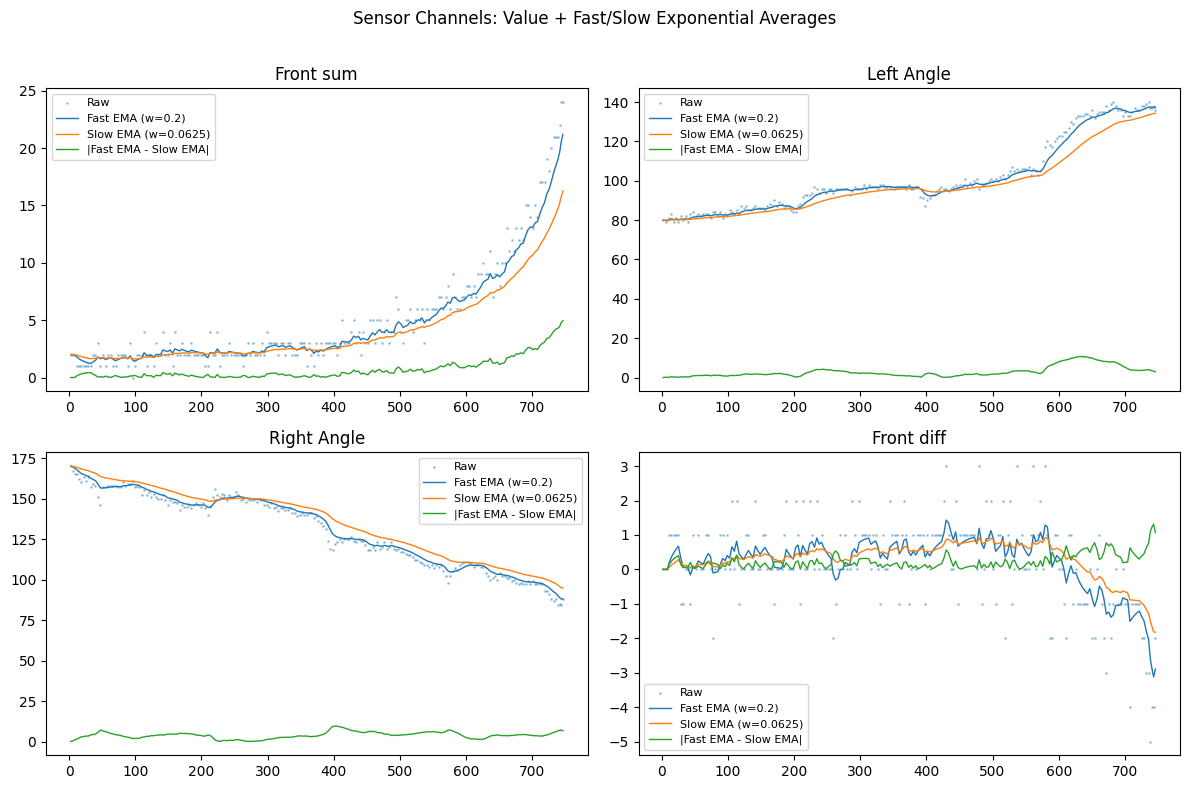

In [198]:
data_csv = Path(log_path)

df = pd.read_csv(data_csv)
fig = plt.figure(figsize=(12, 8))

ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0))
ax4 = plt.subplot2grid((2, 2), (1, 1))

sensor_cols = [
    'Front sum',
    'Left Angle',
    'Right Angle',
    'Front diff',
]

w_fast = 0.2
w_slow = 0.0625

for ax, col in zip((ax1, ax2, ax3, ax4), sensor_cols):
    fast_ema = df[col].ewm(alpha=w_fast, adjust=False).mean()
    slow_ema = df[col].ewm(alpha=w_slow, adjust=False).mean()
    ax.scatter(df['Distance MM'], df[col], s=1, alpha=0.35, label='Raw')
    ax.plot(df['Distance MM'], fast_ema, lw=1, label=f'Fast EMA (w={w_fast})')
    ax.plot(df['Distance MM'], slow_ema, lw=1, label=f'Slow EMA (w={w_slow})')
    ax.plot(df['Distance MM'], (fast_ema - slow_ema).abs(), lw=1, label='|Fast EMA - Slow EMA|')
    ax.set_title(col)
    ax.legend(loc='best', fontsize=8)

fig.suptitle('Sensor Channels: Value + Fast/Slow Exponential Averages')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
